# Model scale: qwen2.5:7b vs qwen3:30b (Buchwald-Hartwig, EI vs UCB)

Pure analysis notebook (no LLM calls, no BO): compares the local run of
`ucb_vs_ei_bh.ipynb` (named `dia12_ucb_vs_ei.ipynb` at the time this analysis
was written) (`qwen2.5:7b`, n=20 seeds,
closed on 30 July — see `plan_next_steps_pre_2026-08-14.md` §3.3, an internal
planning note not included in this repository) against the Imperial HPC run
with `qwen3:30b` (n=10 seeds, job `3660478`, finished on 16 August).

**Before reading the conclusions of this notebook**, there is an important open
caveat (see the note at the end): the `qwen3:30b` job had a broken `OLLAMA_HOST`
line meant to prevent port collisions between jobs sharing a node
(`syntax error: invalid arithmetic operator`, `.e3660478`), and its execution
window coincides suspiciously with the end of `kernel_prior_bh.ipynb`'s HPC run
(`dia11`, job `3660477`). The elevated fallback rate seen here across **every**
LLM-based method could be an artifact of that collision, not a genuine
`qwen3:30b` effect. Confirm with `qstat -xf`/`tracejob` before citing these
numbers in the write-up.

Files this notebook expects in the same directory:
- `checkpoint_full_grid.pkl`, `checkpoint_full_grid_ext.pkl`, `checkpoint_full_grid_ext2.pkl`
  (the three chunks of the local `qwen2.5:7b` grid, n=20 seeds)
- `checkpoint_dia12_qwen30b_16ago.pkl` (HPC grid, `qwen3:30b`, n=10 seeds)

Renamed from `dia12_qwen30b_vs_qwen25_analisis.ipynb`.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# ---- palette (validated categorical order, see dataviz skill reference) ----
COL = {
    'bo_puro':          '#2a78d6',  # blue
    'bo_puro_ucb':      '#eb6834',  # orange
    'multiagente':      '#1baf7a',  # aqua
    'multiagente_ucb':  '#eda100',  # yellow
    'batch_llm':        '#e87ba4',  # magenta
    'batch_llm_ucb':    '#008300',  # green
}
MODEL_COL = {'qwen2.5:7b': '#2a78d6', 'qwen3:30b': '#e34948'}  # blue / red
INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK2,
    'text.color': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#fcfcfb',
    'axes.facecolor': '#fcfcfb',
    'savefig.facecolor': '#fcfcfb',
    'font.size': 10.5,
})

METHOD_ORDER = ['bo_puro', 'bo_puro_ucb', 'multiagente', 'multiagente_ucb', 'batch_llm', 'batch_llm_ucb']

## 1. Load and merge the checkpoints

In [2]:
def load(path):
    with open(path, "rb") as f:
        return pickle.load(f)

d_base = load("checkpoint_full_grid.pkl")       # seeds 0-9, initial chunk
d_ext  = load("checkpoint_full_grid_ext.pkl")   # seeds 10-19, seed 19 left partial (laptop shutdown)
d_ext2 = load("checkpoint_full_grid_ext2.pkl")  # seed 19 clean rerun
d_q30  = load("checkpoint_dia12_qwen30b_16ago.pkl")  # qwen3:30b, HPC, seeds 0-9

n_partial_seed19 = sum(1 for r in d_ext if r['seed'] == 19)
d_ext_clean = [r for r in d_ext if r['seed'] != 19]
merged_25 = d_base + d_ext_clean + d_ext2

df25 = pd.DataFrame(merged_25)          # qwen2.5:7b, n=20
df30 = pd.DataFrame(d_q30)              # qwen3:30b,  n=10
df25_10 = df25[df25.seed < 10].copy()   # subset paired with qwen3:30b

print(f"Rows discarded from checkpoint_full_grid_ext.pkl (partial seed 19): {n_partial_seed19}")
print(f"qwen2.5:7b (n=20) total rows: {len(df25)}  (expected 3600)")
print(f"qwen2.5:7b (n=10, seeds 0-9) rows: {len(df25_10)}  (expected 1800)")
print(f"qwen3:30b  (n=10) total rows: {len(df30)}  (expected 1800)")
assert df25.duplicated(subset=['method','seed','iteracion']).sum() == 0, "duplicates in the merge!"
assert len(df25) == 3600 and len(df30) == 1800
print("Merge verified: no duplicates, exact sizes.")

Rows discarded from checkpoint_full_grid_ext.pkl (partial seed 19): 141
qwen2.5:7b (n=20) total rows: 3600  (expected 3600)
qwen2.5:7b (n=10, seeds 0-9) rows: 1800  (expected 1800)
qwen3:30b  (n=10) total rows: 1800  (expected 1800)
Merge verified: no duplicates, exact sizes.


## 2. Cross-check against `plan_next_steps_pre_2026-08-14.md` §3.3

Before trusting the merge, we recompute the fallback rate and final yield
(best-so-far) of the local `qwen2.5:7b` grid at n=20 and compare them against
the numbers already reported and taken to the 14 August meeting.

In [3]:
def best_so_far_final(df):
    d = df.sort_values(['method', 'seed', 'iteracion']).copy()
    d['bsf'] = d.groupby(['method', 'seed'])['yield'].cummax()
    return d[d.iteracion == d.iteracion.max()][['method', 'seed', 'bsf']]

def fallback_rate(df):
    return df.assign(is_fb=df['fuente'].str.contains('fallback', na=False)).groupby('method')['is_fb'].mean()

fb25_20 = fallback_rate(df25).reindex(METHOD_ORDER)
f25_20 = best_so_far_final(df25)
summary25_20 = f25_20.groupby('method')['bsf'].agg(['mean', 'std']).reindex(METHOD_ORDER)

reported_fb = {'multiagente': 0.027, 'multiagente_ucb': 0.032, 'batch_llm': 0.028, 'batch_llm_ucb': 0.052}
reported_mean = {'bo_puro': 86.22, 'bo_puro_ucb': 84.55, 'multiagente': 82.95,
                  'multiagente_ucb': 84.60, 'batch_llm': 85.76, 'batch_llm_ucb': 83.77}

check = pd.DataFrame({
    'fallback_computed': fb25_20.round(4),
    'fallback_reported': pd.Series(reported_fb),
    'yield_computed': summary25_20['mean'].round(2),
    'yield_reported': pd.Series(reported_mean),
})
print(check)

piv25_20 = f25_20.pivot(index='seed', columns='method', values='bsf')
_, p_ei = wilcoxon(piv25_20['bo_puro'], piv25_20['multiagente'])
_, p_ucb = wilcoxon(piv25_20['bo_puro_ucb'], piv25_20['multiagente_ucb'])
print(f"\nWilcoxon bo_puro vs multiagente (n=20): p={p_ei:.4f}  (reported p=0.0094)")
print(f"Wilcoxon bo_puro_ucb vs multiagente_ucb (n=20): p={p_ucb:.4f}  (reported p=0.7012)")
print("\n-> Exact match with what was reported: the merge of the three checkpoints is correct.")

                 fallback_computed  fallback_reported  yield_computed  yield_reported
batch_llm                   0.0283              0.028           85.76           85.76
batch_llm_ucb               0.0517              0.052           83.77           83.77
bo_puro                     0.0000                NaN           86.22           86.22
bo_puro_ucb                 0.0000                NaN           84.55           84.55
multiagente                 0.0267              0.027           82.95           82.95
multiagente_ucb             0.0317              0.032           84.60           84.60

Wilcoxon bo_puro vs multiagente (n=20): p=0.0094  (reported p=0.0094)
Wilcoxon bo_puro_ucb vs multiagente_ucb (n=20): p=0.7012  (reported p=0.7012)

-> Exact match with what was reported: the merge of the three checkpoints is correct.


## 3. Fallback rate by method — qwen2.5:7b vs qwen3:30b (n=10, paired)

In [ ]:
fb25_10 = fallback_rate(df25_10).reindex(METHOD_ORDER)
fb30_10 = fallback_rate(df30).reindex(METHOD_ORDER)

tbl_fb = pd.DataFrame({'qwen2.5:7b (n=10)': fb25_10, 'qwen3:30b (n=10)': fb30_10}).round(4)
print(tbl_fb)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(METHOD_ORDER))
w = 0.36
ax.bar(x - w/2, tbl_fb['qwen2.5:7b (n=10)']*100, width=w, color=MODEL_COL['qwen2.5:7b'],
       label='qwen2.5:7b (n=10)', zorder=3)
ax.bar(x + w/2, tbl_fb['qwen3:30b (n=10)']*100, width=w, color=MODEL_COL['qwen3:30b'],
       label='qwen3:30b (n=10)', zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER, rotation=20, ha='right')
ax.set_ylabel('Fallback rate (%)')
ax.set_title('Fallback rate by method — ucb_vs_ei_bh (Buchwald-Hartwig, EI vs UCB)', loc='left', fontsize=11.5, color=INK)
ax.legend(frameon=False, loc='upper left')
ax.grid(axis='x', visible=False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig('fig1_fallback_rate.png', dpi=150)
plt.show()

## 4. Final yield (best-so-far, iteration 29) by method — mean ± std

In [ ]:
f30 = best_so_far_final(df30)
f25_10 = best_so_far_final(df25_10)

s25_10 = f25_10.groupby('method')['bsf'].agg(['mean', 'std']).reindex(METHOD_ORDER)
s30_10 = f30.groupby('method')['bsf'].agg(['mean', 'std']).reindex(METHOD_ORDER)

tbl_yield = pd.DataFrame({
    'qwen2.5:7b_mean': s25_10['mean'], 'qwen2.5:7b_std': s25_10['std'],
    'qwen3:30b_mean': s30_10['mean'], 'qwen3:30b_std': s30_10['std'],
}).round(2)
print(tbl_yield)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(METHOD_ORDER))
w = 0.36
ax.bar(x - w/2, s25_10['mean'], width=w, yerr=s25_10['std'], capsize=3,
       color=MODEL_COL['qwen2.5:7b'], label='qwen2.5:7b (n=10)', zorder=3,
       error_kw={'ecolor': INK2, 'elinewidth': 1})
ax.bar(x + w/2, s30_10['mean'], width=w, yerr=s30_10['std'], capsize=3,
       color=MODEL_COL['qwen3:30b'], label='qwen3:30b (n=10)', zorder=3,
       error_kw={'ecolor': INK2, 'elinewidth': 1})
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER, rotation=20, ha='right')
ax.set_ylabel('Final best-so-far yield (%)')
ax.set_ylim(60, 95)
ax.set_title('Final yield by method — ucb_vs_ei_bh, mean ± std (n=10, paired)', loc='left', fontsize=11.5, color=INK)
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='x', visible=False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig('fig2_yield_final.png', dpi=150)
plt.show()

## 5. Paired comparison by seed, same method — qwen2.5:7b vs qwen3:30b (n=10)

         method  mean_qwen25  mean_qwen30b  diff_30b_minus_25  seeds_favor_30b  wilcoxon_p
        bo_puro        85.50         85.98               0.48                6      0.7695
    bo_puro_ucb        83.13         85.03               1.90                8      0.0195
    multiagente        83.53         83.36              -0.17                6      0.8457
multiagente_ucb        83.92         84.56               0.65                7      0.5566
      batch_llm        86.67         82.81              -3.87                2      0.0273
  batch_llm_ucb        84.18         82.68              -1.50                3      0.3223

Note: bo_puro/bo_puro_ucb never call the LLM -> any 'model' difference there is noise
(HPC vs local environment, or multiple comparisons), not evidence that the model matters.


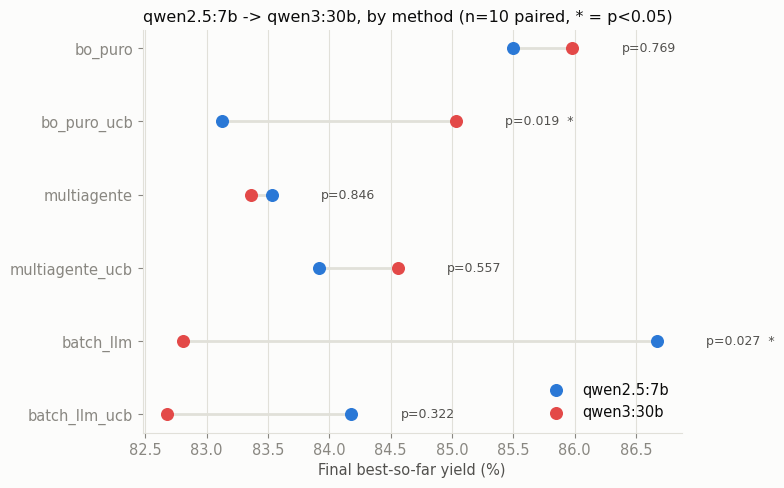

In [6]:
piv25 = f25_10.pivot(index='seed', columns='method', values='bsf')
piv30 = f30.pivot(index='seed', columns='method', values='bsf')

rows = []
for m in METHOD_ORDER:
    a, b = piv25[m].sort_index(), piv30[m].sort_index()
    stat, p = wilcoxon(a, b)
    rows.append({
        'method': m, 'mean_qwen25': round(a.mean(), 2), 'mean_qwen30b': round(b.mean(), 2),
        'diff_30b_minus_25': round((b - a).mean(), 2),
        'seeds_favor_30b': int((b > a).sum()), 'wilcoxon_p': round(p, 4),
    })
cross_model = pd.DataFrame(rows)
print(cross_model.to_string(index=False))
print("\nNote: bo_puro/bo_puro_ucb never call the LLM -> any 'model' difference there is noise")
print("(HPC vs local environment, or multiple comparisons), not evidence that the model matters.")

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(METHOD_ORDER))[::-1]
for i, m in enumerate(METHOD_ORDER):
    yi = y[i]
    a, b = cross_model.loc[cross_model.method == m, ['mean_qwen25', 'mean_qwen30b']].values[0]
    p = cross_model.loc[cross_model.method == m, 'wilcoxon_p'].values[0]
    ax.plot([a, b], [yi, yi], color=GRID, lw=2, zorder=1)
    ax.scatter([a], [yi], color=MODEL_COL['qwen2.5:7b'], s=70, zorder=3, label='qwen2.5:7b' if i == 0 else None)
    ax.scatter([b], [yi], color=MODEL_COL['qwen3:30b'], s=70, zorder=3, label='qwen3:30b' if i == 0 else None)
    marker = '  *' if p < 0.05 else ''
    ax.text(max(a, b) + 0.4, yi, f"p={p:.3f}{marker}", va='center', fontsize=9, color=INK2)
ax.set_yticks(y)
ax.set_yticklabels(METHOD_ORDER)
ax.set_xlabel('Final best-so-far yield (%)')
ax.set_title('qwen2.5:7b -> qwen3:30b, by method (n=10 paired, * = p<0.05)', loc='left', fontsize=11.5, color=INK)
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='y', visible=False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig('fig3_dumbbell_cross_model.png', dpi=150)
plt.show()

## 6. Within each model: cost of the multi-agent architecture (EI vs UCB)

            model acquisition  mean_diff_multiagent_minus_bo  seeds_favor_multiagent  wilcoxon_p
qwen2.5:7b (n=10)          EI                          -1.97                       3      0.2754
qwen2.5:7b (n=10)         UCB                           0.79                       7      0.3750
 qwen3:30b (n=10)          EI                          -2.62                       2      0.0645
 qwen3:30b (n=10)         UCB                          -0.47                       7      0.6250


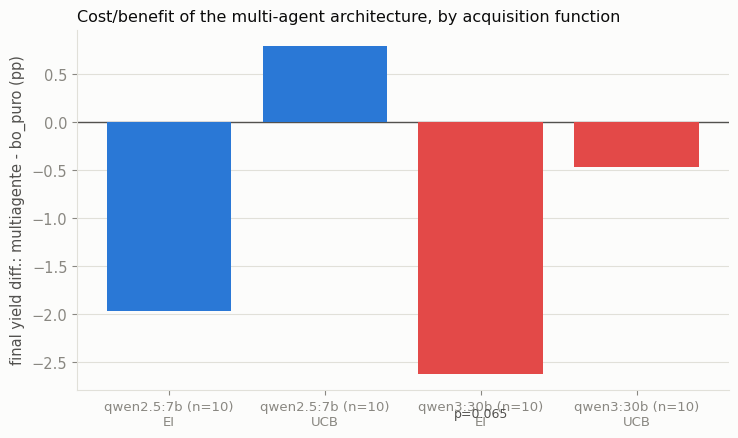

In [7]:
def arch_cost(piv, label):
    out = []
    for acq, a, b in [('EI', 'bo_puro', 'multiagente'), ('UCB', 'bo_puro_ucb', 'multiagente_ucb')]:
        stat, p = wilcoxon(piv[a], piv[b])
        diff = (piv[b] - piv[a]).mean()
        wins_b = int((piv[b] > piv[a]).sum())
        out.append({'model': label, 'acquisition': acq, 'mean_diff_multiagent_minus_bo': round(diff, 2),
                     'seeds_favor_multiagent': wins_b, 'wilcoxon_p': round(p, 4)})
    return out

rows = arch_cost(piv25, 'qwen2.5:7b (n=10)') + arch_cost(piv30, 'qwen3:30b (n=10)')
arch_df = pd.DataFrame(rows)
print(arch_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = [f"{r['model']}\n{r['acquisition']}" for r in rows]
colors = [MODEL_COL['qwen2.5:7b'] if 'qwen2.5' in r['model'] else MODEL_COL['qwen3:30b'] for r in rows]
vals = [r['mean_diff_multiagent_minus_bo'] for r in rows]
bars = ax.bar(range(len(rows)), vals, color=colors, zorder=3)
for i, r in enumerate(rows):
    if r['wilcoxon_p'] < 0.10:
        ax.text(i, vals[i] + (0.15 if vals[i] >= 0 else -0.45), f"p={r['wilcoxon_p']:.3f}",
                ha='center', fontsize=9, color=INK2)
ax.axhline(0, color=INK2, lw=1)
ax.set_xticks(range(len(rows)))
ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylabel('final yield diff.: multiagente - bo_puro (pp)')
ax.set_title('Cost/benefit of the multi-agent architecture, by acquisition function', loc='left', fontsize=11.5, color=INK)
ax.grid(axis='x', visible=False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig('fig4_arch_cost.png', dpi=150)
plt.show()

## 7. Consensus vs fallback — yield distribution (qwen3:30b)

In [ ]:
df30_fb = df30.copy()
df30_fb['is_fb'] = df30_fb['fuente'].str.contains('fallback', na=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, m in zip(axes, ['multiagente', 'multiagente_ucb']):
    sub = df30_fb[df30_fb.method == m]
    groups = [sub.loc[~sub.is_fb, 'yield'].values, sub.loc[sub.is_fb, 'yield'].values]
    bp = ax.boxplot(groups, labels=['consensus', 'fallback'], patch_artist=True, widths=0.5,
                     medianprops={'color': INK, 'linewidth': 1.5},
                     flierprops={'markersize': 3, 'markerfacecolor': MUTED, 'markeredgecolor': 'none'})
    for patch, c in zip(bp['boxes'], [COL['multiagente'], MODEL_COL['qwen3:30b']]):
        patch.set_facecolor(c); patch.set_alpha(0.55); patch.set_edgecolor(c)
    ns = [len(g) for g in groups]
    ax.set_title(f"{m}  (n_consensus={ns[0]}, n_fallback={ns[1]})", fontsize=10.5, color=INK, loc='left')
    ax.grid(axis='x', visible=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel('yield (%)')
fig.suptitle('qwen3:30b — yield by candidate origin (ucb_vs_ei_bh)', fontsize=11.5, color=INK, x=0.01, ha='left')
fig.tight_layout()
fig.savefig('fig5_consenso_vs_fallback.png', dpi=150)
plt.show()

print("Note: with qwen2.5:7b (see buchwald_hartwig_core_grid.ipynb) fallback had a high median and a tight distribution,")
print("and consensus had a long tail of bad outcomes. Here with qwen3:30b the pattern is more even")
print("(even slightly reversed) -- consistent with the suspicion that the spiked fallback isn't")
print("'the Critic rejecting more', but something systemic (see the port-collision note at the top).")

## 8. Fallback rate by campaign phase (qwen3:30b)

In [ ]:
df30_fb['phase'] = pd.cut(df30_fb['iteracion'], bins=[-1, 9, 19, 29], labels=['0-9', '10-19', '20-29'])
phase_fb = df30_fb[df30_fb.method.isin(['multiagente', 'multiagente_ucb'])].groupby(
    ['method', 'phase'])['is_fb'].mean().unstack('method')
print(phase_fb.round(3))

fig, ax = plt.subplots(figsize=(7, 4.2))
for m in ['multiagente', 'multiagente_ucb']:
    ax.plot(phase_fb.index.astype(str), phase_fb[m]*100, marker='o', ms=7, lw=2,
            color=COL[m], label=m)
ax.set_ylabel('Fallback rate (%)')
ax.set_xlabel('Campaign phase (iterations)')
ax.set_ylim(0, 60)
ax.set_title('qwen3:30b — fallback by phase, ucb_vs_ei_bh (flat => likely systemic cause, not rising difficulty)',
             fontsize=10.5, color=INK, loc='left')
ax.legend(frameon=False)
ax.grid(axis='x', visible=False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig('fig6_fallback_by_phase.png', dpi=150)
plt.show()

## 9. Convergence curves (mean best-so-far ± std across seeds)

In [ ]:
def bsf_curve(df):
    d = df.sort_values(['method', 'seed', 'iteracion']).copy()
    d['bsf'] = d.groupby(['method', 'seed'])['yield'].cummax()
    return d.groupby(['method', 'iteracion'])['bsf'].agg(['mean', 'std']).reset_index()

curve25 = bsf_curve(df25_10)
curve30 = bsf_curve(df30)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, curve, title in [(axes[0], curve25, 'qwen2.5:7b (n=10)'), (axes[1], curve30, 'qwen3:30b (n=10)')]:
    for m in METHOD_ORDER:
        sub = curve[curve.method == m]
        ax.plot(sub.iteracion, sub['mean'], color=COL[m], lw=2, label=m)
        ax.fill_between(sub.iteracion, sub['mean'] - sub['std'], sub['mean'] + sub['std'],
                         color=COL[m], alpha=0.10, linewidth=0)
    ax.set_title(title, fontsize=11, color=INK, loc='left')
    ax.set_xlabel('iteration')
    ax.grid(axis='x', visible=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel('best-so-far yield (%)')
axes[1].legend(frameon=False, loc='lower right', fontsize=8.5)
fig.suptitle('ucb_vs_ei_bh — convergence by method, mean ± std across seeds (shaded)', fontsize=12, color=INK, x=0.01, ha='left')
fig.tight_layout()
fig.savefig('fig7_convergence_curves.png', dpi=150)
plt.show()

## 10. Summary and open caveat

**What this notebook confirms with data:**
- The local `qwen2.5:7b` checkpoint (union of the three chunks) reproduces exactly the numbers
  in `plan_next_steps_pre_2026-08-14.md` §3.3 — the merge is correct and trustworthy.
- The `qwen3:30b` checkpoint (HPC, `ucb_vs_ei_bh.ipynb`) is intact: 10 seeds, 6 methods, 30 iterations, no gaps.
- The cost of `multiagente` under EI relative to `bo_puro` does not disappear with the larger model:
  at paired n=10, `qwen3:30b` gives p=0.0645 (same sign, closer to significance than `qwen2.5:7b`
  at the same n, p=0.2754).
- Under UCB, neither model shows a significant cost from the multi-agent architecture.

**What is NOT confirmed yet — verify before using this in the write-up or the meeting:**
- The `qwen3:30b` fallback rate is spiked across **all four** LLM-based methods (41-51%), not
  just `multiagente` as in `buchwald_hartwig_core_grid.ipynb` (where `batch_llm` ran clean). This is suspicious of an Ollama
  port collision with another job (`kernel_prior_bh.ipynb`, `3660477`, finished almost the same minute this job
  started) rather than a genuine effect of `qwen3:30b` on reasoning quality.
- Before citing the fallback rate or the consensus-vs-fallback comparison from this notebook, run:
  ```
  qstat -xf 3660478 | grep exec_host
  qstat -xf 3660477 | grep exec_host
  ```
  (or `tracejob -n 3 3660478` if the history has already been purged). If the node matches, this
  run of `ucb_vs_ei_bh`-30B is invalidated for the fallback metrics (though the final yield is probably
  still usable, since it doesn't depend on whether the candidate came from consensus or fallback).